In [1]:
import ufl
from dolfinx import fem
from mpi4py import MPI
from dolfinx.io import gmsh
import vtk
import meshio
import numpy as np
from vtk.util.numpy_support import vtk_to_numpy
from scipy.spatial import cKDTree
from dolfinx import mesh, fem, io, plot
from scipy.interpolate import RBFInterpolator
from types import SimpleNamespace
import basix
import dolfinx.fem.petsc
from dolfinx.fem.petsc import NonlinearProblem
from pathlib import Path



# LOCAL FRAME
def normalize(v):
    return v / ufl.sqrt(ufl.dot(v, v))

def _local_frame_ufl(domain):
    t  = ufl.Jacobian(domain)
    t1 = ufl.as_vector([t[0, 0], t[1, 0], t[2, 0]])
    t2 = ufl.as_vector([t[0, 1], t[1, 1], t[2, 1]])
    e3 = normalize(ufl.cross(t1, t2))
    ey = ufl.as_vector([0, 1, 0])
    ez = ufl.as_vector([0, 0, 1])
    e1_trial = ufl.cross(ey, e3)
    norm_e1  = ufl.sqrt(ufl.dot(e1_trial, e1_trial))
    e1 = ufl.conditional(ufl.lt(norm_e1, 0.5), ez, normalize(e1_trial))
    e2 = normalize(ufl.cross(e3, e1))
    return e1, e2, e3

def local_frame(domain, gdim):
    FRAME  = _local_frame_ufl(domain)
    VT     = fem.functionspace(domain, ("DG", 0, (gdim,)))
    V0, _  = VT.sub(0).collapse()
    BASIS  = [fem.Function(VT, name=f"Basis_vector_e{i+1}") for i in range(gdim)]
    for i in range(gdim):
        e_exp = fem.Expression(FRAME[i], V0.element.interpolation_points)
        BASIS[i].interpolate(e_exp)
    return BASIS[0], BASIS[1], BASIS[2]


# SHELL KINEMATICS
def hstack(vecs):
    return ufl.as_matrix([[vi[i] for i in range(len(vi))] for vi in vecs]).T

def tangent_projection(e1, e2):
    return hstack([e1, e2])

def tangential_gradient(w, P):
    return ufl.dot(ufl.grad(w), P)

def membrane_strain(u, P):
    t_gu = ufl.dot(P.T, tangential_gradient(u, P))
    return ufl.sym(t_gu), t_gu

def bending_strain(theta, e3, P):
    beta = ufl.cross(e3, theta)
    return ufl.sym(ufl.dot(P.T, tangential_gradient(beta, P)))

def shear_strain(u, theta, e3, P):
    beta = ufl.cross(e3, theta)
    return tangential_gradient(ufl.dot(u, e3), P) - ufl.dot(P.T, beta)

def compute_drilling_strain(t_gu, theta, e3):
    return (t_gu[0, 1] - t_gu[1, 0]) / 2 + ufl.dot(theta, e3)

def shell_strains(u, theta, e1, e2, e3):
    P                 = tangent_projection(e1, e2)
    eps, t_gu         = membrane_strain(u, P)
    kappa             = bending_strain(theta, e3, P)
    gamma             = shear_strain(u, theta, e3, P)
    drilling_strain   = compute_drilling_strain(t_gu, theta, e3)
    return eps, kappa, gamma, drilling_strain



# ISOTROPIC MATERIAL
def isotropic_material(thickness, young, poisson, domain):
    h        = fem.Constant(domain, float(thickness))
    E        = fem.Constant(domain, float(young))
    nu       = fem.Constant(domain, float(poisson))
    lmbda    = E * nu / (1 + nu) / (1 - 2 * nu)
    mu       = E / 2 / (1 + nu)
    lmbda_ps = 2 * lmbda * mu / (lmbda + 2 * mu)
    return SimpleNamespace(h=h, E=E, nu=nu, lmbda=lmbda, mu=mu, lmbda_ps=lmbda_ps, kind="isotropic")

# CLT COMPOSITE MATERIAL
def _Q_ply(E1, E2, G12, nu12):
    nu21 = nu12 * E2 / E1
    d    = 1 - nu12 * nu21
    return np.array([
        [ E1 / d,        nu12 * E2 / d,  0   ],
        [ nu12 * E2 / d, E2 / d,         0   ],
        [ 0,             0,              G12 ],
    ])


def _Qbar_ply(Q, angle_deg):
    a    = np.radians(angle_deg)
    c, s = np.cos(a), np.sin(a)
    T = np.array([
        [ c**2,   s**2,   2*c*s          ],
        [ s**2,   c**2,  -2*c*s          ],
        [-c*s,    c*s,    c**2 - s**2    ],
    ])
    R    = np.diag([1.0, 1.0, 2.0])
    Rinv = np.diag([1.0, 1.0, 0.5])
    return np.linalg.inv(T) @ Q @ R @ T @ Rinv

def compute_ABD(layup_angles, t_ply, E1, E2, G12, nu12):
    Q   = _Q_ply(E1, E2, G12, nu12)
    H   = t_ply * len(layup_angles)
    z   = -H / 2.0
    A   = np.zeros((3, 3))
    B   = np.zeros((3, 3))
    D   = np.zeros((3, 3))
    for angle in layup_angles:
        Qb = _Qbar_ply(Q, angle)
        z0, z1 = z, z + t_ply
        A += Qb * (z1 - z0)
        B += Qb * (z1**2 - z0**2) / 2.0
        D += Qb * (z1**3 - z0**3) / 3.0
        z  = z1
    return A, B, D, H

def clt_material(layup_angles, t_ply,E1, E2, G12, nu12,G13=None, G23=None, kappa_s=5/6):
    if G13 is None: G13 = G12
    if G23 is None: G23 = G12 * 0.5

    A_np, B_np, D_np, H = compute_ABD(layup_angles, t_ply, E1, E2, G12, nu12)

    max_B = np.abs(B_np).max()
    print(f"[CLT] Layup  : {layup_angles}")
    print(f"[CLT] H      : {H*1e3:.2f} mm")
    print(f"[CLT] max|B| : {max_B:.2e}  {'SYMMETRIC' if max_B < 1e-6 * A_np.max() else 'NON-SYMMETRIC'}")
    print(f"[CLT] A11    : {A_np[0,0]/1e6:.2f} MPa·m")
    print(f"[CLT] D11    : {D_np[0,0]:.4f} N·m²")

    As_np = kappa_s * H * np.array([
        [ G13, 0.0 ],
        [ 0.0, G23 ],
    ])

    # EFFECTIVE IN-PLANE SHEAR FOR DRILLING STABILISATION
    G_eff = float(A_np[2, 2]) / H

    return SimpleNamespace(
        kind   = "clt",
        H      = H,
        A_np   = A_np,
        B_np   = B_np,
        D_np   = D_np,
        As_np  = As_np,
        G_eff  = G_eff,
        A_ufl  = ufl.as_tensor(A_np),
        B_ufl  = ufl.as_tensor(B_np),
        D_ufl  = ufl.as_tensor(D_np),
        As_ufl = ufl.as_tensor(As_np),
    )

# VOIGT NOTATION
def to_voigt(e):
    return ufl.as_vector([e[0, 0], e[1, 1], 2.0 * e[0, 1]])


def from_voigt(v):
    return ufl.as_tensor([
        [v[0], v[2]],
        [v[2], v[1]],
    ])


# SHELL STRESS RESULTANTS
def _plane_stress_iso(mat, e):
    tdim = e.ufl_shape[0]
    return mat.lmbda_ps * ufl.tr(e) * ufl.Identity(tdim) + 2 * mat.mu * e


def stress_resultants(mat, eps, kappa, gamma):
    if mat.kind == "isotropic":
        N = mat.h * _plane_stress_iso(mat, eps)
        M = mat.h**3 / 12.0 * _plane_stress_iso(mat, kappa)
        Q = mat.mu * mat.h * gamma

    elif mat.kind == "clt":
        eps_v   = to_voigt(eps)
        kappa_v = to_voigt(kappa)

        N_v = ufl.dot(mat.A_ufl, eps_v) + ufl.dot(mat.B_ufl, kappa_v)
        M_v = ufl.dot(mat.B_ufl, eps_v) + ufl.dot(mat.D_ufl, kappa_v)

        N   = from_voigt(N_v)
        M   = from_voigt(M_v)
        Q   = ufl.dot(mat.As_ufl, gamma)

    else:
        raise ValueError(f"Unknown material kind: {mat.kind!r}")
    return N, M, Q


def drilling_terms(mat, domain, drilling_strain):
    h_mesh = ufl.CellDiameter(domain)

    if mat.kind == "isotropic":
        G_eff = mat.mu
    else:
        G_eff = fem.Constant(domain, mat.G_eff)

    h = mat.h if mat.kind == "isotropic" else fem.Constant(domain, mat.H)

    stiffness = G_eff * h**3 / h_mesh**2
    stress    = stiffness * drilling_strain
    return stiffness, stress


# IMPORT AND MAP OPENFOAM DATA
def import_foam_traction(foamfile, xdmffile, verbose=False):
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(foamfile)
    reader.Update()
    poly = reader.GetOutput()

    tri = vtk.vtkTriangleFilter()
    tri.SetInputData(poly)
    tri.Update()
    poly = tri.GetOutput()

    points = vtk_to_numpy(poly.GetPoints().GetData())
    p      = vtk_to_numpy(poly.GetPointData().GetArray("p"))
    wss    = vtk_to_numpy(poly.GetPointData().GetArray("wallShearStress"))

    cells = poly.GetPolys()
    cells.InitTraversal()
    idList = vtk.vtkIdList()
    triangles = []
    while cells.GetNextCell(idList):
        triangles.append([idList.GetId(i) for i in range(3)])
    triangles = np.array(triangles)

    P0 = points[triangles[:, 0]]
    P1 = points[triangles[:, 1]]
    P2 = points[triangles[:, 2]]

    v1 = P1 - P0
    v2 = P2 - P0
    n  = np.cross(v1, v2)

    area = 0.5 * np.linalg.norm(n, axis=1)
    n_unit = n / np.linalg.norm(n, axis=1)[:, None]

    p_tri   = p[triangles].mean(axis=1)
    wss_tri = wss[triangles].mean(axis=1)

    traction_cell = -p_tri[:, None] * n_unit + wss_tri

    nodal_traction = np.zeros_like(points)
    nodal_area     = np.zeros(len(points))

    for i, tri in enumerate(triangles):
        for j in tri:
            nodal_traction[j] += traction_cell[i] * area[i] / 3.0
            nodal_area[j]     += area[i] / 3.0

    nodal_traction /= nodal_area[:, None]

    if verbose:
        total_force = (traction_cell * area[:, None]).sum(axis=0)
        print("[FOAM] Total OpenFOAM force:", total_force)

    meshio.write(xdmffile, meshio.Mesh(
        points=points,
        cells=[("triangle", triangles)],
        point_data={"traction": nodal_traction},
    ))

    print(f"[FOAM] Exported traction to the file {xdmffile}")

def map_traction(foamfile, femfile, outfile):
    fm  = meshio.read(foamfile)
    fp  = fm.points
    ft  = fm.points[fm.cells_dict["triangle"]] if "triangle" not in fm.cells_dict else fp
    ft  = fm.point_data["traction"]
    fp  = fm.points

    sm  = meshio.read(femfile)
    sp  = sm.points * 1e-3
    st  = sm.cells_dict["triangle"]

    interp         = RBFInterpolator(fp, ft, kernel="thin_plate_spline", neighbors=20)
    nodal_traction = interp(sp)

    trib_area = np.zeros(len(sp))
    for tri in st:
        P0, P1, P2 = sp[tri[0]], sp[tri[1]], sp[tri[2]]
        area = 0.5 * np.linalg.norm(np.cross(P1 - P0, P2 - P0))
        for j in tri:
            trib_area[j] += area / 3.0
    nodal_force = nodal_traction * trib_area[:, np.newaxis]

    foam_tri  = fm.cells_dict["triangle"]
    foam_area = 0.5 * np.linalg.norm(
        np.cross(fp[foam_tri[:, 1]] - fp[foam_tri[:, 0]],
                 fp[foam_tri[:, 2]] - fp[foam_tri[:, 0]]), axis=1)
    foam_tract = ft[foam_tri].mean(axis=1)
    foam_force = (foam_tract * foam_area[:, np.newaxis]).sum(axis=0)
    fem_force  = nodal_force.sum(axis=0)
    err        = np.linalg.norm(fem_force - foam_force) / np.linalg.norm(foam_force)
    print(f"[MAP] FOAM force [N] : {foam_force}")
    print(f"[MAP] FEM  force [N] : {fem_force}")
    print(f"[MAP] Force error    : {err*100:.2f}%")

    meshio.write(outfile, meshio.Mesh(
        points=sp,
        cells=[("triangle", st)],
        point_data={"traction": nodal_traction},
    ))
    print(f"[MAP] Saved =====> {outfile}")
    return nodal_force


def load_traction_xdmf(xdmffile, domain, gdim):
    data   = meshio.read(xdmffile)
    pts    = data.points
    tract  = data.point_data["traction"]

    VT     = fem.functionspace(domain, ("Lagrange", 1, (gdim,)))
    f      = fem.Function(VT, name="traction")
    coords = VT.tabulate_dof_coordinates()

    print(f"[LOAD] FEM pts range : {domain.geometry.x.min(axis=0)} =====> {domain.geometry.x.max(axis=0)}")
    print(f"[LOAD] XDMF pts range : {pts.min(axis=0)} =====> {pts.max(axis=0)}")

    tree = cKDTree(pts)
    dist, idx = tree.query(coords, k=1)
    print(f"[LOAD] Max KDTree dist : {dist.max():.4e} m   (should be < 1e-3 m)")

    f.x.array[:] = tract[idx].flatten()
    f.x.scatter_forward()
    return f





# FAILURE CRITERIA (post-processing)
def tsai_wu(sigma_mat, strengths):
    s1, s2, s6 = sigma_mat
    Xt, Xc     = strengths["Xt"], strengths["Xc"]
    Yt, Yc     = strengths["Yt"], strengths["Yc"]
    S          = strengths["S"]

    F1  =  1/Xt - 1/Xc
    F2  =  1/Yt - 1/Yc
    F11 =  1/(Xt*Xc)
    F22 =  1/(Yt*Yc)
    F66 =  1/S**2
    F12 = -0.5 / np.sqrt(Xt * Xc * Yt * Yc)

    return (F1*s1 + F2*s2
            + F11*s1**2 + F22*s2**2
            + F66*s6**2 + 2*F12*s1*s2)


def hashin(sigma_mat, strengths):
    s1, s2, s6 = sigma_mat
    Xt, Xc     = strengths["Xt"], strengths["Xc"]
    Yt, Yc     = strengths["Yt"], strengths["Yc"]
    SL         = strengths["S"]
    ST         = strengths.get("ST", Yc / 2.0)

    out = {}
    if s1 >= 0:
        out["fiber_t"] = (s1/Xt)**2 + (s6/SL)**2
    else:
        out["fiber_c"] = (s1/Xc)**2

    if s2 >= 0:
        out["matrix_t"] = (s2/Yt)**2 + (s6/SL)**2
    else:
        out["matrix_c"] = ((s2/(2*ST))**2 + (Yc/(2*ST))**2 * (s2/Yc) + (s6/SL)**2)
    return out


def recover_and_evaluate_failure(domain, v_sol, mat, strengths, criterion="tsai_wu"):
    assert mat.kind == "clt", "Failure recovery requires CLT material"

    u_h, theta_h = ufl.split(v_sol)
    e1, e2, e3   = local_frame(domain, domain.geometry.dim)
    P            = tangent_projection(e1, e2)
    eps_h, _     = membrane_strain(u_h, P)
    kappa_h      = bending_strain(theta_h, e3, P)

    DG0    = fem.functionspace(domain, ("DG", 0, (3,)))
    eps_fn = fem.Function(DG0)
    kap_fn = fem.Function(DG0)

    eps_fn.interpolate(fem.Expression(to_voigt(eps_h),   DG0.element.interpolation_points))
    kap_fn.interpolate(fem.Expression(to_voigt(kappa_h), DG0.element.interpolation_points))

    eps0_vals  = eps_fn.x.array.reshape(-1, 3)
    kappa_vals = kap_fn.x.array.reshape(-1, 3)

    layup   = mat._layup_angles
    t_ply   = mat._t_ply
    Q_ply   = _Q_ply(mat._E1, mat._E2, mat._G12, mat._nu12)

    H   = mat.H
    z   = -H / 2.0
    FI_all = []

    for angle in layup:
        z_mid    = z + t_ply / 2.0
        strain_k = eps0_vals + z_mid * kappa_vals

        Qb_lam    = _Qbar_ply(Q_ply, angle)
        stress_lam = strain_k @ Qb_lam.T

        a = np.radians(angle)
        c, s = np.cos(a), np.sin(a)
        T = np.array([
            [ c**2,  s**2,  2*c*s       ],
            [ s**2,  c**2, -2*c*s       ],
            [-c*s,   c*s,   c**2 - s**2 ],
        ])
        stress_mat = stress_lam @ T.T

        if criterion == "tsai_wu":
            FI_k = np.array([tsai_wu(s, strengths) for s in stress_mat])
        else:
            FI_k = np.array([max(hashin(s, strengths).values()) for s in stress_mat])

        FI_all.append(FI_k)
        print(f"  ply {angle:+4.0f} deg  max FI = {FI_k.max():.4f}")
        z += t_ply

    FI_all = np.array(FI_all)
    FI_max = FI_all.max()
    print(f"\n[FAIL] Global max FI : {FI_max:.4f}  =====>  SF = {1/FI_max:.2f}")
    return FI_max, FI_all






MESHFILE = "skin.msh"
FOAMFILE = "../wing.vtp"
XDMFFILE = "FOAMData.xdmf"
MAPFILE  = "MappedTraction.xdmf"

# LOAD MESH
MESH = gmsh.read_from_msh(MESHFILE, comm=MPI.COMM_WORLD, gdim=3)
DOMAIN = MESH.mesh
DOMAIN.geometry.x[:] *= 1E-3
CELL_TAGS = MESH.cell_tags
FACET_TAGS = MESH.facet_tags
GDIM = DOMAIN.geometry.dim
TDIM = DOMAIN.topology.dim
FDIM = TDIM - 1


# LOCAL FRAME
E1, E2, E3 = local_frame(DOMAIN, GDIM)

RESULTS_FOLDER = Path("LocalFrame")
RESULTS_FOLDER .mkdir(exist_ok=True, parents=True)
with io.VTKFile(MPI.COMM_WORLD, RESULTS_FOLDER / "LocalFrame.pvd", "w") as vtk_f:
    vtk_f.write_mesh(DOMAIN)
    vtk_f.write_function(E1, 0.0)
    vtk_f.write_function(E2, 0.0)
    vtk_f.write_function(E3, 0.0)

# FUNCTION SPACE
Ue          = basix.ufl.element("P",  DOMAIN.basix_cell(), 2, shape=(GDIM,))
Te          = basix.ufl.element("CR", DOMAIN.basix_cell(), 1, shape=(GDIM,))
V           = fem.functionspace(DOMAIN, basix.ufl.mixed_element([Ue, Te]))
v           = fem.Function(V)
u, theta    = ufl.split(v)
v_          = ufl.TestFunction(V)
u_, theta_  = ufl.split(v_)
dv          = ufl.TrialFunction(V)

# SHELL KINEMATIC
eps, kappa, gamma, drilling_strain = shell_strains(u, theta, E1, E2, E3)
eps_             = ufl.derivative(eps,            v, v_)
kappa_           = ufl.derivative(kappa,          v, v_)
gamma_           = ufl.derivative(gamma,          v, v_)
drilling_strain_ = ufl.replace(drilling_strain,  {v: v_})

# MATERIAL
# Toggle between isotropic and CLT by commenting/uncommenting one block.
# OPTION A: ISOTROPIC MATERIAL
# PURPOSE: USED FOR VALIDATION
# USAGE: MAT = isotropic_material(thickness, young, poisson, domain=DOMAIN)
# OPTION B: CLT COMPOSITE
# PURPOSE: USED FOR MAIN OPTIMIZATION
_E1, _E2, _G12, _nu12 = 181E9, 10.3E9, 7.17E9, 0.28
_t_ply  = 0.75E-3
_layup  = [0, 45, -45, 90, 90, -45, 45, 0]

MAT = clt_material(
    layup_angles = _layup,
    t_ply        = _t_ply,
    E1  = _E1,  E2  = _E2,  G12 = _G12,  nu12 = _nu12,
    G13 = _G12, G23 = _G12 * 0.5,
    kappa_s = 5/6,
)

MAT._layup_angles = _layup
MAT._t_ply  = _t_ply
MAT._E1     = _E1;  MAT._E2  = _E2
MAT._G12    = _G12; MAT._nu12 = _nu12

N, M, Q = stress_resultants(MAT, eps, kappa, gamma)
_, drilling_stress = drilling_terms(MAT, DOMAIN, drilling_strain)

ROOT_FACETS = FACET_TAGS.find(11)

Vu, _         = V.sub(0).collapse()
root_dofs_u   = fem.locate_dofs_topological((V.sub(0), Vu), FDIM, ROOT_FACETS)
uD            = fem.Function(Vu);  uD.x.array[:] = 0.0

Vt, _         = V.sub(1).collapse()
root_dofs_t   = fem.locate_dofs_topological((V.sub(1), Vt), FDIM, ROOT_FACETS)
thetaD        = fem.Function(Vt);  thetaD.x.array[:] = 0.0

BCS = [
    fem.dirichletbc(uD,     root_dofs_u, V.sub(0)),
    fem.dirichletbc(thetaD, root_dofs_t, V.sub(1)),
]


# LOAD AND MAP TRACTION FROM OPENFOAM
import_foam_traction(FOAMFILE, XDMFFILE, verbose=True)
map_traction(XDMFFILE, MESHFILE, MAPFILE)
FTraction = load_traction_xdmf(MAPFILE, DOMAIN, GDIM)




# WEAK FORMULATION
dx = ufl.Measure("dx", DOMAIN)

a_int = (
    ufl.inner(N, eps_)
    + ufl.inner(M, kappa_)
    + ufl.inner(Q, gamma_)
    + drilling_stress * drilling_strain_
) * dx

L_ext    = ufl.dot(FTraction, u_) * dx
residual = a_int - L_ext
tangent  = ufl.derivative(residual, v, dv)



# SOLVE
problem = NonlinearProblem(
    F=residual, u=v, bcs=BCS, J=tangent,
    petsc_options_prefix="wing",
    petsc_options={
        "ksp_type"                   : "preonly",
        "pc_type"                    : "lu",
        "pc_factor_mat_solver_type"  : "mumps",
        "snes_type"                  : "newtonls",
        "snes_rtol"                  : 1e-8,
        "snes_atol"                  : 1e-8,
        "snes_max_it"                : 25,
        "snes_monitor"               : None,
    },
)
problem.solve()

converged = problem.solver.getConvergedReason()
n_iter    = problem.solver.getIterationNumber()
print(f"[SNES] converged reason : {converged}")
print(f"[SNES] iterations       : {n_iter}")
assert converged > 0, f"Solver did not converge (reason {converged})"

# POST-PROCESSING
disp = v.sub(0).collapse()
rota = v.sub(1).collapse()
disp.name = "Displacement"
rota.name = "Rotation"

vdim_u   = disp.function_space.element.value_shape[0]
disp_arr = disp.x.array.reshape(-1, vdim_u)
disp_mag = np.linalg.norm(disp_arr, axis=1)
local_max  = disp_mag.max()
global_max = MPI.COMM_WORLD.allreduce(local_max, op=MPI.MAX)
print(f"\n[POST] Max displacement magnitude : {global_max:.6e} m")

if MAT.kind == "clt":
    STRENGTHS = {
        "Xt": 1500e6, "Xc": 900e6,
        "Yt":   50e6, "Yc": 200e6,
        "S":    70e6,
    }
    print("\n[POST] Tsai-Wu failure indices per ply:")
    FI_max, FI_all = recover_and_evaluate_failure(
        DOMAIN, v, MAT, STRENGTHS, criterion="tsai_wu"
    )

# EXPORT SOLUTION 
RESULT_FOLDER = Path("Result")
RESULT_FOLDER.mkdir(exist_ok=True, parents=True)

Vout      = fem.functionspace(DOMAIN, ("Lagrange", 1, (GDIM,)))
disp_out  = fem.Function(Vout); disp_out.interpolate(disp); disp_out.name = "Displacement"
rota_out  = fem.Function(Vout); rota_out.interpolate(rota);  rota_out.name = "Rotation"

with io.XDMFFile(MPI.COMM_WORLD, RESULT_FOLDER / "results.xdmf", "w") as xdmf:
    xdmf.write_mesh(DOMAIN)
    xdmf.write_function(disp_out)
    xdmf.write_function(rota_out)

print(f"[EXPORT] Results written to {RESULT_FOLDER / 'results.xdmf'}")

## CLEANUP
# problem.solver.destroy()

Info    : Reading 'skin.msh'...
Info    : 3280 nodes
Info    : 6560 elements
Info    : Done reading 'skin.msh'
[CLT] Layup  : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.82e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 2309.1921 N·m²
[FOAM] Total OpenFOAM force: [ -1159.2976   4449.0146 -17788.746 ]
[FOAM] Exported traction to the file FOAMData.xdmf

[MAP] FOAM force [N] : [ -1159.4213   4448.869  -17789.004 ]
[MAP] FEM  force [N] : [ -1200.00438549   4606.87837857 -17879.90229553]
[MAP] Force error    : 1.02%
[MAP] Saved =====> MappedTraction.xdmf
[LOAD] FEM pts range : [ 1.13686838e-16  2.27373675e-16 -7.78196237e-02] =====> [2.499403   3.         0.04446707]
[LOAD] XDMF pts range : [ 1.13686838e-16  2.27373675e-16 -7.78196237e-02] =====> [2.499403   3.         0.04446707]
[LOAD] Max KDTree dist : 6.2808e-16 m   (should be < 1e-3 m)
  0 SNES Function norm 2.344337734797e+03
  1 SNES Function norm 3.978105708053e-06
[SNES] converged reason : 3


In [2]:
import numpy as np
from mpi4py import MPI
from slepc4py import SLEPc

# -------------------------------------------------
# 1️⃣  Helper: solve buckling for a given layup
# -------------------------------------------------
def compute_buckling_for_layup(layup_angles):

    global MAT, N, M, Q, drilling_stress, a_int, residual, tangent, problem

    # --- rebuild material
    MAT = clt_material(
        layup_angles=layup_angles,
        t_ply=_t_ply,
        E1=_E1, E2=_E2, G12=_G12, nu12=_nu12,
        G13=_G12, G23=_G12*0.5,
        kappa_s=5/6,
    )

    MAT._layup_angles = layup_angles
    MAT._t_ply = _t_ply
    MAT._E1 = _E1
    MAT._E2 = _E2
    MAT._G12 = _G12
    MAT._nu12 = _nu12

    # --- rebuild stress resultants
    N, M, Q = stress_resultants(MAT, eps, kappa, gamma)
    _, drilling_stress = drilling_terms(MAT, DOMAIN, drilling_strain)

    a_int = (
        ufl.inner(N, eps_)
        + ufl.inner(M, kappa_)
        + ufl.inner(Q, gamma_)
        + drilling_stress * drilling_strain_
    ) * dx

    residual = a_int - L_ext
    tangent = ufl.derivative(residual, v, dv)

    problem = NonlinearProblem(
        F=residual,
        u=v,
        bcs=BCS,
        J=tangent,
        petsc_options_prefix="sens",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "snes_type": "newtonls",
        },
    )

    v.x.array[:] = 0.0
    v.x.scatter_forward()
    problem.solve()

    # --- compute membrane forces for KG
    u_h, theta_h = ufl.split(v)
    P = tangent_projection(E1, E2)
    eps_h, _ = membrane_strain(u_h, P)
    kap_h = bending_strain(theta_h, E3, P)
    gam_h = shear_strain(u_h, theta_h, E3, P)
    N_h, _, _ = stress_resultants(MAT, eps_h, kap_h, gam_h)

    # --- geometric stiffness
    w = ufl.TrialFunction(V)
    v_test = ufl.TestFunction(V)
    u_w, _ = ufl.split(w)
    u_v, _ = ufl.split(v_test)

    w_n = ufl.dot(u_w, E3)
    v_n = ufl.dot(u_v, E3)

    grad_w = tangential_gradient(w_n, P)
    grad_v = tangential_gradient(v_n, P)

    # a_G = - ufl.inner(ufl.dot(N_h, grad_w), grad_v) * dx
    a_G = ufl.inner(ufl.dot(N_h, grad_w), grad_v) * dx

    K_form = fem.form(tangent)
    KG_form = fem.form(a_G)

    K = fem.petsc.assemble_matrix(K_form, bcs=BCS)
    K.assemble()

    KG = fem.petsc.assemble_matrix(KG_form)
    KG.assemble()

    # zero constrained rows/cols in KG
    bc_dofs = np.unique(
        np.concatenate([bc.dof_indices()[0] for bc in BCS])
    )
    KG.zeroRowsColumns(bc_dofs, 0.0)

    # --- eigen solve
    eigensolver = SLEPc.EPS().create(MPI.COMM_WORLD)
    eigensolver.setOperators(K, KG)
    eigensolver.setProblemType(SLEPc.EPS.ProblemType.GNHEP)

    ST = eigensolver.getST()
    ST.setType(SLEPc.ST.Type.SINVERT)

    eigensolver.setTarget(1.0)
    eigensolver.setWhichEigenpairs(SLEPc.EPS.Which.TARGET_REAL)
    eigensolver.setDimensions(nev=10)
    eigensolver.solve()

    nconv = eigensolver.getConverged()

    lambdas = []
    vr = K.createVecRight()
    vi = K.createVecRight()

    for i in range(nconv):
        lam = eigensolver.getEigenpair(i, vr, vi)
        if lam.real > 0:
            lambdas.append(lam.real)

    if len(lambdas) == 0:
        return None

    return min(lambdas)

In [5]:
print("\n=== Sensitivity: λ1 vs 0° fraction ===")

total_plies = 8
n_half = total_plies // 2
results = []

for n0 in range(0, n_half + 1):
    n_off  = n_half - n0
    half   = [0] * n0 + [45] * (n_off // 2) + [-45] * (n_off - n_off // 2)
    layup  = half + half[::-1]
    frac_0 = layup.count(0) / total_plies

    lambda_cr = compute_buckling_for_layup(layup)   # sign fixed inside

    if MPI.COMM_WORLD.rank == 0:
        status = f"λ₁ = {lambda_cr:.4f}" if lambda_cr else "⚠️  no positive eigenvalue"
        print(f"  {layup}  |  0° fraction = {frac_0:.2f}  |  {status}")

    results.append((frac_0, lambda_cr))


=== Sensitivity: λ1 vs 0° fraction ===
[CLT] Layup  : [45, 45, -45, -45, -45, -45, 45, 45]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 339.95 MPa·m
[CLT] D11    : 1019.8402 N·m²
  [45, 45, -45, -45, -45, -45, 45, 45]  |  0° fraction = 0.00  |  λ₁ = 0.6026
[CLT] Layup  : [0, 45, -45, -45, -45, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 6.91e-11  SYMMETRIC
[CLT] A11    : 527.68 MPa·m
[CLT] D11    : 2322.2172 N·m²
  [0, 45, -45, -45, -45, -45, 45, 0]  |  0° fraction = 0.25  |  λ₁ = 0.9063
[CLT] Layup  : [0, 0, 45, -45, -45, 45, 0, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 715.41 MPa·m
[CLT] D11    : 2991.0055 N·m²
  [0, 0, 45, -45, -45, 45, 0, 0]  |  0° fraction = 0.50  |  λ₁ = 0.8981
[CLT] Layup  : [0, 0, 0, -45, -45, 0, 0, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 903.14 MPa·m
[CLT] D11    : 3237.4011 N·m²
  [0, 0, 0, -45, -45, 0, 0, 0]  |  0° fraction = 0.75  |  λ₁ = 0.5991
[CLT] La

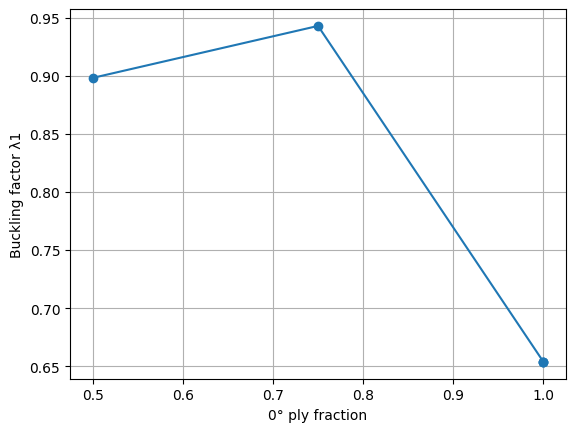

In [4]:
import matplotlib.pyplot as plt

fractions = [r[0] for r in results]
lams = [r[1] for r in results]

plt.plot(fractions, lams, 'o-')
plt.xlabel("0° ply fraction")
plt.ylabel("Buckling factor λ1")
plt.grid(True)
plt.show()

In [7]:
total_plies = 8
n_half = total_plies // 2   # = 4
results = []

for n0 in range(0, n_half + 1):   # n0 = 0,1,2,3,4
    n_off = n_half - n0

    # Phân chia n_off plies: dùng ±45 theo cặp, 90° lấp chỗ lẻ
    n_pairs_45 = n_off // 2         # số cặp ±45
    n_90       = n_off % 2          # 0 hoặc 1 ply 90°

    half   = [0]*n0 + [45]*n_pairs_45 + [-45]*n_pairs_45 + [90]*n_90
    layup  = half + half[::-1]      # symmetric

    # Verification
    assert len(layup) == total_plies,          f"Wrong length: {layup}"
    assert layup.count(45) == layup.count(-45), f"Unbalanced ±45: {layup}"
    # 90° tự balance → A16 = 0 đảm bảo

    frac_0 = layup.count(0) / total_plies
    lambda_cr = compute_buckling_for_layup(layup)

    if MPI.COMM_WORLD.rank == 0:
        print(f"  {layup}  |  0°={frac_0:.2f}  |  λ₁={lambda_cr:.4f}")

    results.append((frac_0, lambda_cr))

[CLT] Layup  : [45, 45, -45, -45, -45, -45, 45, 45]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 339.95 MPa·m
[CLT] D11    : 1019.8402 N·m²
  [45, 45, -45, -45, -45, -45, 45, 45]  |  0°=0.00  |  λ₁=0.6026
[CLT] Layup  : [0, 45, -45, 90, 90, -45, 45, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.82e-11  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 2309.1921 N·m²
  [0, 45, -45, 90, 90, -45, 45, 0]  |  0°=0.25  |  λ₁=1.1995
[CLT] Layup  : [0, 0, 45, -45, -45, 45, 0, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 715.41 MPa·m
[CLT] D11    : 2991.0055 N·m²
  [0, 0, 45, -45, -45, 45, 0, 0]  |  0°=0.50  |  λ₁=0.8981
[CLT] Layup  : [0, 0, 0, 90, 90, 0, 0, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11    : 833.67 MPa·m
[CLT] D11    : 3224.3760 N·m²
  [0, 0, 0, 90, 90, 0, 0, 0]  |  0°=0.75  |  λ₁=0.8684
[CLT] Layup  : [0, 0, 0, 0, 0, 0, 0, 0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 5.82e-11  SYMMETRIC
[CLT] A11 

In [9]:
def normalize_angle(theta):
    """
    Normalize ply angle về (-90, 90].
    Ví dụ: 105° → -75°,  150° → -30°,  -75° → -75°
    Convention chuẩn trong CLT — Q̄(θ) = Q̄(θ + 180°)
    """
    theta = theta % 180      # đưa về [0, 180)
    if theta > 90:
        theta -= 180         # đưa về (-90, 90]
    return theta

# --- Quick test để verify trước khi chạy sweep ---
test_cases = [
    (0,    0),
    (60,   60),
    (90,   90),
    (105, -75),
    (150, -30),
    (180,   0),
    (-45, -45),
    (-75, -75),
]
all_pass = True
for inp, expected in test_cases:
    result = normalize_angle(inp)
    status = "✅" if result == expected else "❌"
    if result != expected:
        all_pass = False
    print(f"  {status}  normalize_angle({inp:>4d}°) = {result:>4.0f}°  (expected {expected}°)")

print(f"\n{'✅ All tests passed' if all_pass else '❌ Fix normalize_angle before continuing'}")

  ✅  normalize_angle(   0°) =    0°  (expected 0°)
  ✅  normalize_angle(  60°) =   60°  (expected 60°)
  ✅  normalize_angle(  90°) =   90°  (expected 90°)
  ✅  normalize_angle( 105°) =  -75°  (expected -75°)
  ✅  normalize_angle( 150°) =  -30°  (expected -30°)
  ✅  normalize_angle( 180°) =    0°  (expected 0°)
  ✅  normalize_angle( -45°) =  -45°  (expected -45°)
  ✅  normalize_angle( -75°) =  -75°  (expected -75°)

✅ All tests passed


In [10]:
# Sensitivity sweep in swept frame

psi = 60.0  # sweep angle

results_swept = []
for delta in [0, 15, 30, 45]:   # deviation từ sweep direction
    half = [
        psi,
        psi + 45 + delta,
        psi - 45 - delta,
        psi + 90,
    ]
    layup = [normalize_angle(a) for a in half + half[::-1]]
    
    lambda_cr = compute_buckling_for_layup(layup)
    
    if MPI.COMM_WORLD.rank == 0:
        print(f"  δ={delta:2d}°  layup={layup}  λ₁={lambda_cr:.4f}")
    
    results_swept.append((delta, lambda_cr))

[CLT] Layup  : [60.0, -75.0, 15.0, -30.0, -30.0, 15.0, -75.0, 60.0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 1.24e-10  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 656.7638 N·m²
  δ= 0°  layup=[60.0, -75.0, 15.0, -30.0, -30.0, 15.0, -75.0, 60.0]  λ₁=0.9976
[CLT] Layup  : [60.0, -60.0, 0.0, -30.0, -30.0, 0.0, -60.0, 60.0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 8.00e-11  SYMMETRIC
[CLT] A11    : 507.73 MPa·m
[CLT] D11    : 761.1400 N·m²
  δ=15°  layup=[60.0, -60.0, 0.0, -30.0, -30.0, 0.0, -60.0, 60.0]  λ₁=1.0142
[CLT] Layup  : [60.0, -45.0, -15.0, -30.0, -30.0, -15.0, -45.0, 60.0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.46e-11  SYMMETRIC
[CLT] A11    : 525.23 MPa·m
[CLT] D11    : 895.5272 N·m²
  δ=30°  layup=[60.0, -45.0, -15.0, -30.0, -30.0, -15.0, -45.0, 60.0]  λ₁=0.9843
[CLT] Layup  : [60.0, -30.0, -30.0, -30.0, -30.0, -30.0, -30.0, 60.0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.46e-11  SYMMETRIC
[CLT] A11    : 527.68 MPa·m
[CLT] D11    : 1076.6727 N·m²
  δ=45°  layup=[60.0, -30.0,

In [12]:
def check_angle_diversity(layup, min_distinct=3):
    """Kiểm tra layup có đủ diverse angles không"""
    unique_angles = set(round(a, 1) for a in layup)
    if len(unique_angles) < min_distinct:
        return False, unique_angles
    return True, unique_angles


psi = 60.0
results_swept = []

for delta in [0, 15, 30, 45]:
    half = [
        psi,
        psi + 45 + delta,
        psi - 45 - delta,
        psi + 90,
    ]
    layup = [normalize_angle(a) for a in half + half[::-1]]

    # ✅ continue nằm đúng trong loop
    valid, unique_angles = check_angle_diversity(layup)
    if not valid:
        if MPI.COMM_WORLD.rank == 0:
            print(f"  ⚠️  δ={delta:2d}°  SKIP — degenerate: only {len(unique_angles)} "
                  f"distinct angles {sorted(unique_angles)}")
        continue

    lambda_cr = compute_buckling_for_layup(layup)

    if MPI.COMM_WORLD.rank == 0:
        print(f"  δ={delta:2d}°  layup={layup}  λ₁={lambda_cr:.4f}")

    results_swept.append((delta, lambda_cr))

[CLT] Layup  : [60.0, -75.0, 15.0, -30.0, -30.0, 15.0, -75.0, 60.0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 1.24e-10  SYMMETRIC
[CLT] A11    : 458.21 MPa·m
[CLT] D11    : 656.7638 N·m²
  δ= 0°  layup=[60.0, -75.0, 15.0, -30.0, -30.0, 15.0, -75.0, 60.0]  λ₁=0.9976
[CLT] Layup  : [60.0, -60.0, 0.0, -30.0, -30.0, 0.0, -60.0, 60.0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 8.00e-11  SYMMETRIC
[CLT] A11    : 507.73 MPa·m
[CLT] D11    : 761.1400 N·m²
  δ=15°  layup=[60.0, -60.0, 0.0, -30.0, -30.0, 0.0, -60.0, 60.0]  λ₁=1.0142
[CLT] Layup  : [60.0, -45.0, -15.0, -30.0, -30.0, -15.0, -45.0, 60.0]
[CLT] H      : 6.00 mm
[CLT] max|B| : 9.46e-11  SYMMETRIC
[CLT] A11    : 525.23 MPa·m
[CLT] D11    : 895.5272 N·m²
  δ=30°  layup=[60.0, -45.0, -15.0, -30.0, -30.0, -15.0, -45.0, 60.0]  λ₁=0.9843
  ⚠️  δ=45°  SKIP — degenerate: only 2 distinct angles [-30.0, 60.0]
